<a href="https://colab.research.google.com/github/Decoding-Data-Science/airesidency/blob/main/LlamaParse_project_cohort9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

|Year Ended December 31|2023|2024|
|---|---|---|
|Net cash provided by (used in) operating activities|84,946|115,877|
|Purchases of property and equipment, net of proceeds from sales and incentives|(48,133)|(77,658)|
|Free cash flow|36,813|38,219|
|Net cash provided by (used in) investing activities|(49,833)|(94,342)|
|Net cash provided by (used in) financing activities|(15,879)|(11,812)|

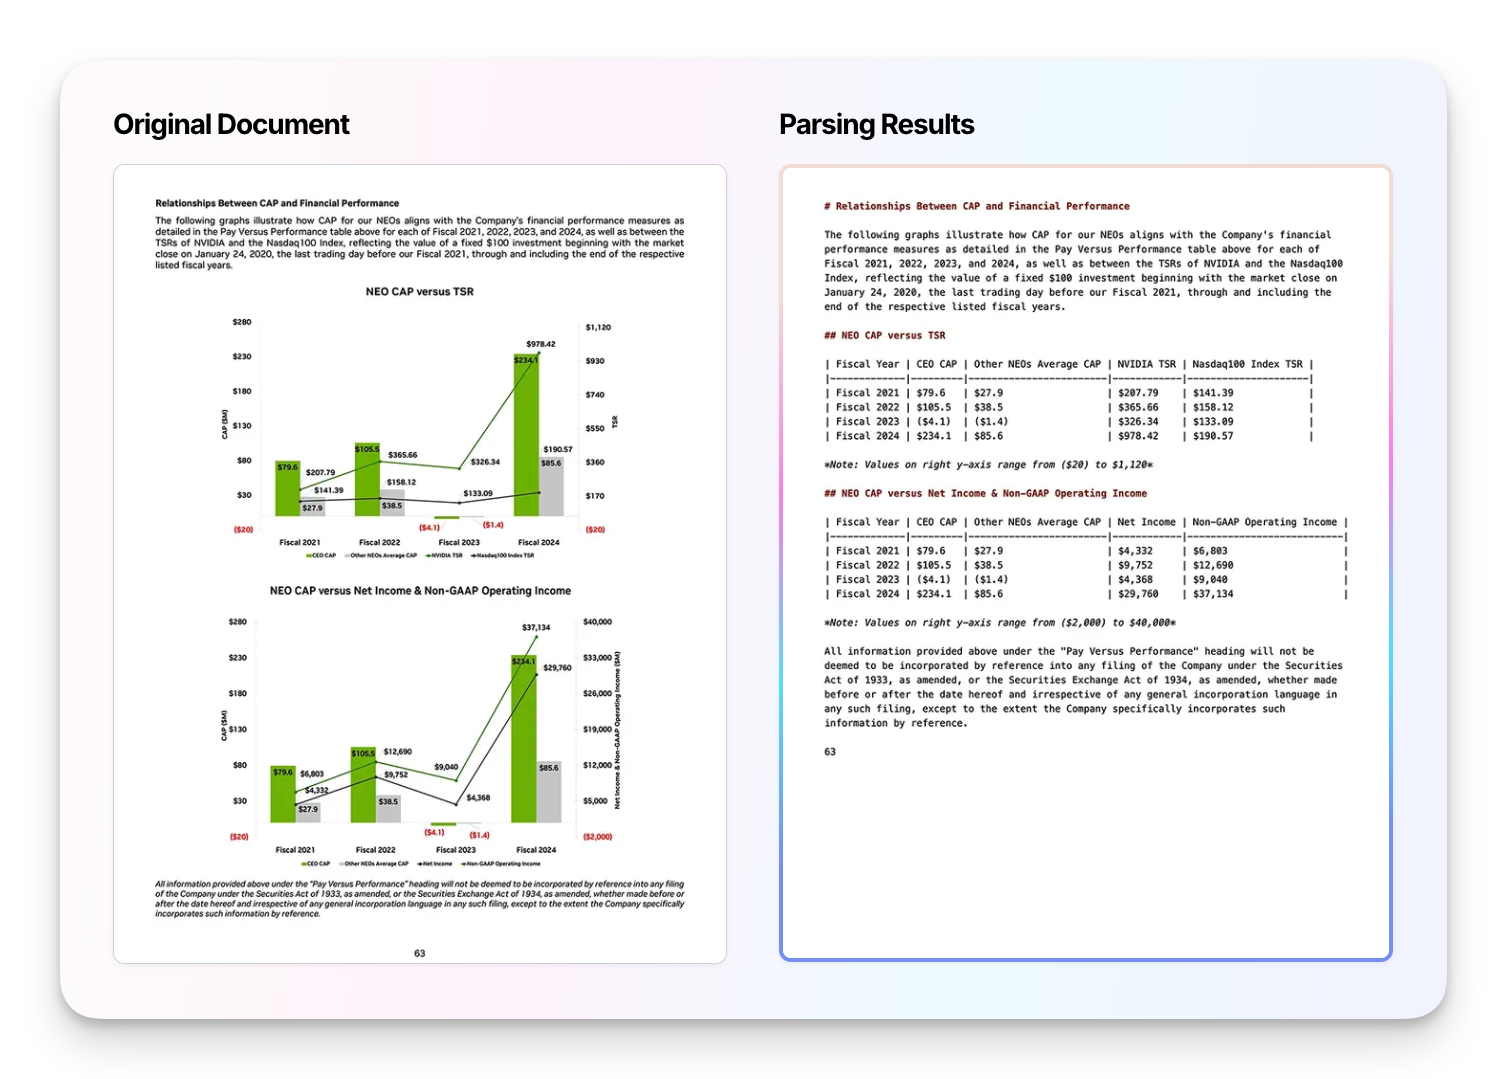

In [ ]:
%pip install llama-parse


In [2]:
!wget "https://s2.q4cdn.com/470004039/files/doc_financials/2021/q4/_10-K-2021-(As-Filed).pdf" -O apple_10k.pdf


--2026-03-21 09:58:57--  https://s2.q4cdn.com/470004039/files/doc_financials/2021/q4/_10-K-2021-(As-Filed).pdf
Resolving s2.q4cdn.com (s2.q4cdn.com)... 68.70.205.1, 68.70.205.3, 68.70.205.4, ...
Connecting to s2.q4cdn.com (s2.q4cdn.com)|68.70.205.1|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 789896 (771K) [application/pdf]
Saving to: ‘apple_10k.pdf’

apple_10k.pdf       100%[===================>] 771.38K  --.-KB/s    in 0.03s   

2026-03-21 09:58:57 (24.3 MB/s) - ‘apple_10k.pdf’ saved [789896/789896]



In [3]:
import os
from google.colab import userdata
os.environ["LLAMA_CLOUD_API_KEY"] = userdata.get('llama')


In [11]:
import nest_asyncio

nest_asyncio.apply()

In [12]:
from llama_parse import LlamaParse

document = LlamaParse(result_type="markdown").load_data("/content/apple_10k.pdf")

Started parsing the file under job_id d45de2c9-e3ed-4020-80e0-539b0dee6ac7


In [ ]:
document

In [14]:
print(document[0].text[:2000])


# UNITED STATES SECURITIES AND EXCHANGE COMMISSION

# Washington, D.C. 20549

# FORM 10-K

# (Mark One)

☒ ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934

For the fiscal year ended September 25, 2021

or

☐ TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934

For the transition period from   to  .

Commission File Number: 001-36743

# Apple Inc.

(Exact name of Registrant as specified in its charter)

| California                        | 94-2404110                           |
| --------------------------------- | ------------------------------------ |
| (State or other jurisdiction      | (I.R.S. Employer Identification No.) |
| of incorporation or organization) |                                      |

One Apple Park Way

Cupertino, California 95014

(Address of principal executive offices) (Zip Code)

(408) 996-1010

(Registrant’s telephone number, including area code)

# Securities registered pursuant to Se


| Title of each class                        | Trading symbol(s) | Name of each exchange on which registered |
| ------------------------------------------ | ----------------- | ----------------------------------------- |
| Common Stock, $0.00001 par value per share | AAPL              | The Nasdaq Stock Market LLC               |
| 1.000% Notes due 2022                      | —                 | The Nasdaq Stock Market LLC               |
| 1.375% Notes due 2024                      | —                 | The Nasdaq Stock Market LLC               |
| 0.000% Notes due 2025                      | —                 | The Nasdaq Stock Market LLC               |
| 0.875% Notes due 2025                      | —                 | The Nasdaq Stock Market LLC               |
| 1.625% Notes due 2026                      | —                 | The Nasdaq Stock Market LLC               |
| 2.000% Notes due 2027                      | —                 | The Nasdaq Stock Mar

In [15]:
import openai
from google.colab import userdata

# Retrieve the OpenAI API key from Google Colab secrets
openai.api_key = userdata.get('openai')

In [16]:
file_name = "apple_10k.md"
with open(file_name, 'w') as file:
    file.write(document[0].text)

In [17]:
documents_with_instruction = LlamaParse(
    result_type="markdown",
    parsing_instruction="""
    This is the Apple annual report. Make sure the language english if not translate it to english
    """
    ).load_data("/content/apple_10k.pdf")

Started parsing the file under job_id bfb0081d-c179-428b-ae86-037db686eaa3


In [18]:
documents_with_instruction_hindi = LlamaParse(
    result_type="markdown",
    parsing_instruction="""
    translate in hindi
    """
    ).load_data("/content/apple_10k.pdf")

Started parsing the file under job_id e91b8bcf-2185-4330-b966-b4e41a67dc6c
.

In [ ]:
file_name = "apple_10k_instructions.md"
with open(file_name, 'w') as file:
    file.write(documents_with_instruction[0].text)

In [19]:
file_name = "apple_10k_instructions_hindi.md"
with open(file_name, 'w') as file:
    file.write(documents_with_instruction_hindi[0].text)

In [ ]:
pip install llama-index-embeddings-openai

In [ ]:
pip install llama-index

In [ ]:
from llama_index.core import VectorStoreIndex, SimpleDirectoryReader

# 1. Make sure the file is there
!ls -lh apple_10k.md apple_10k_instructions.md

# 2. Load the doc(s) into LlamaIndex
reader = SimpleDirectoryReader(input_files=["apple_10k_instructions.md"])
docs = reader.load_data()

# 3. Build index
index = VectorStoreIndex.from_documents(docs)

# 4. Get a query engine
query_engine = index.as_query_engine(similarity_top_k=5)


-rw-r--r-- 1 root root 1.1K Nov  1 14:18 apple_10k_instructions.md
-rw-r--r-- 1 root root 2.8K Nov  1 14:13 apple_10k.md


In [ ]:
response = query_engine.query(
    "Summarize Apple's business performance for the year, highlight revenue, profit, and any major risks mentioned."
)
print(response)


Apple Inc. had a strong business performance for the fiscal year ending September 25, 2021. The company reported significant revenue and profit growth during this period. However, there were also major risks highlighted in the report that could impact the company's future performance.
